<a href="https://colab.research.google.com/github/r-karra/ML4Sci-QMLHEP-GSoC2026-Evaluation/blob/r-karra-patch-1/circuit_implementations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task I: Quantum Computing Circuits

Implementation of two quantum circuits using PennyLane framework.

## Part 1: Multi-qubit Circuit with Hadamard, CNOT, SWAP, and Rotation
## Part 2: Swap Test Circuit

## Setup and Imports

In [1]:
!pip install pennylane
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

print("PennyLane version:", qml.__version__)

PennyLane version: 0.44.1


# Part 1: Circuit 1 - Multi-Qubit Operations

**Requirements:**
- 5 qubits
- Hadamard gate on every qubit
- CNOT gates: (0,1), (1,2), (2,3), (3,4)
- SWAP on qubits (0,4)
- RX(π/2) rotation on any qubit

## Part 1: Multi-Qubit Operations with JAX

This section re-implements Circuit 1 using the JAX backend for PennyLane, allowing for JIT compilation and automatic differentiation capabilities provided by JAX.



---

### PennyLane Circuit 1

1.  **Device Initialization**: `dev1 = qml.device('default.qubit', wires=5)` initializes a quantum simulator from PennyLane, specifying that it should simulate a generic qubit system with 5 qubits.

2.  **QNode Definition**: The `@qml.qnode(dev1)` decorator turns the `circuit_1` function into a quantum node, which means PennyLane will process and execute its operations on the specified device.

3.  **`circuit_1()` Function**: This function defines the quantum circuit's operations:
    *   **Hadamard Gates**: A `qml.Hadamard` gate is applied to each of the 5 qubits, putting them into a superposition state ($ket{+}$ or $ket{-}$).
    *   **CNOT Chain**: A sequence of `qml.CNOT` (Controlled-NOT) gates is applied. The control and target qubits for each CNOT operation are: (0,1), (1,2), (2,3), and (3,4). This creates entanglement between neighboring qubits.
    *   **SWAP Gate**: A `qml.SWAP` gate exchanges the quantum states of qubit 0 and qubit 4.
    *   **RX Gate**: A `qml.RX(np.pi/2, wires=2)` gate applies a rotation around the X-axis by an angle of $\pi/2$ (90 degrees) to qubit 2.
    *   **Expectation Values**: The circuit is configured to return the expectation value of the Pauli-Z operator ($<Z>$) for each of the 5 qubits. This gives an average value of the measurement outcomes for each qubit if measured in the Z-basis.

4.  **Circuit Execution**: `result1 = circuit_1()` runs the PennyLane quantum circuit on the simulator and stores the calculated expectation values in `result1`.

5.  **Output**: The expectation values are then printed.

In [2]:
import pennylane as qml
import jax.numpy as jnp

# Define a device with 5 qubits for JAX execution
dev_jax = qml.device('default.qubit', wires=5)

@qml.qnode(dev_jax, interface='jax')
def circuit_1_jax():
    """
    Circuit 1 (JAX version): Multi-qubit gates demonstration

    Operations in order:
    1. Hadamard gates on all 5 qubits
    2. CNOT chain: (0,1), (1,2), (2,3), (3,4)
    3. SWAP operation between qubits 0 and 4
    4. RX(π/2) rotation on qubit 2
    """

    # Step 1: Apply Hadamard to all qubits
    for qubit in range(5):
        qml.Hadamard(wires=qubit)

    # Step 2: Apply CNOT chain
    cnot_pairs = [(0, 1), (1, 2), (2, 3), (3, 4)]
    for control, target in cnot_pairs:
        qml.CNOT(wires=[control, target])

    # Step 3: Apply SWAP between qubits 0 and 4
    qml.SWAP(wires=[0, 4])

    # Step 4: Apply RX(π/2) on qubit 2 using jax.numpy
    qml.RX(jnp.pi/2, wires=2)

    # Return expectation values (Z measurement on all qubits)
    return [qml.expval(qml.PauliZ(i)) for i in range(5)]

# Run the JAX circuit
result1_jax = circuit_1_jax()
print("\n=== CIRCUIT 1 (JAX) RESULTS ===")
print(f"Expectation values of Z on all qubits: {result1_jax}")


=== CIRCUIT 1 (JAX) RESULTS ===
Expectation values of Z on all qubits: [Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32)]


### Visualization of Circuit 1 (JAX)

This diagram visualizes a 5-qubit quantum circuit:

*   **Qubits 0-4**: Represented by horizontal lines.
*   **Hadamard (H)**: Applied to all qubits at the start, creating superposition.
*   **CNOT (Controlled-NOT)**:
    *   `●` (control qubit), `X` (target qubit).
    *   A chain of CNOTs: (0,1), (1,2), (2,3), (3,4), creating entanglement.
*   **SWAP**:
    *   `╭SWAP` / `╰SWAP` symbol.
    *   Exchanges the states of Qubit 0 and Qubit 4.
*   **RX($\pi/2$)**:
    *   `RX(1.57)` symbol (since $\pi/2 \approx 1.57$).
    *   A rotation around the X-axis by $\pi/2$ radians applied to Qubit 2.
*   **Expectation Value ($<Z>$)**: `┤ <Z>` at the end of each qubit line indicates a measurement of the Pauli-Z observable.

In [3]:
print("\n=== CIRCUIT 1 (JAX) DIAGRAM ===")
print(qml.draw(circuit_1_jax)())


=== CIRCUIT 1 (JAX) DIAGRAM ===
0: ──H─╭●──────────╭SWAP───────────┤  <Z>
1: ──H─╰X─╭●───────│───────────────┤  <Z>
2: ──H────╰X─╭●────│──────RX(1.57)─┤  <Z>
3: ──H───────╰X─╭●─│───────────────┤  <Z>
4: ──H──────────╰X─╰SWAP───────────┤  <Z>


## Detailed Circuit Visualization with Matplotlib

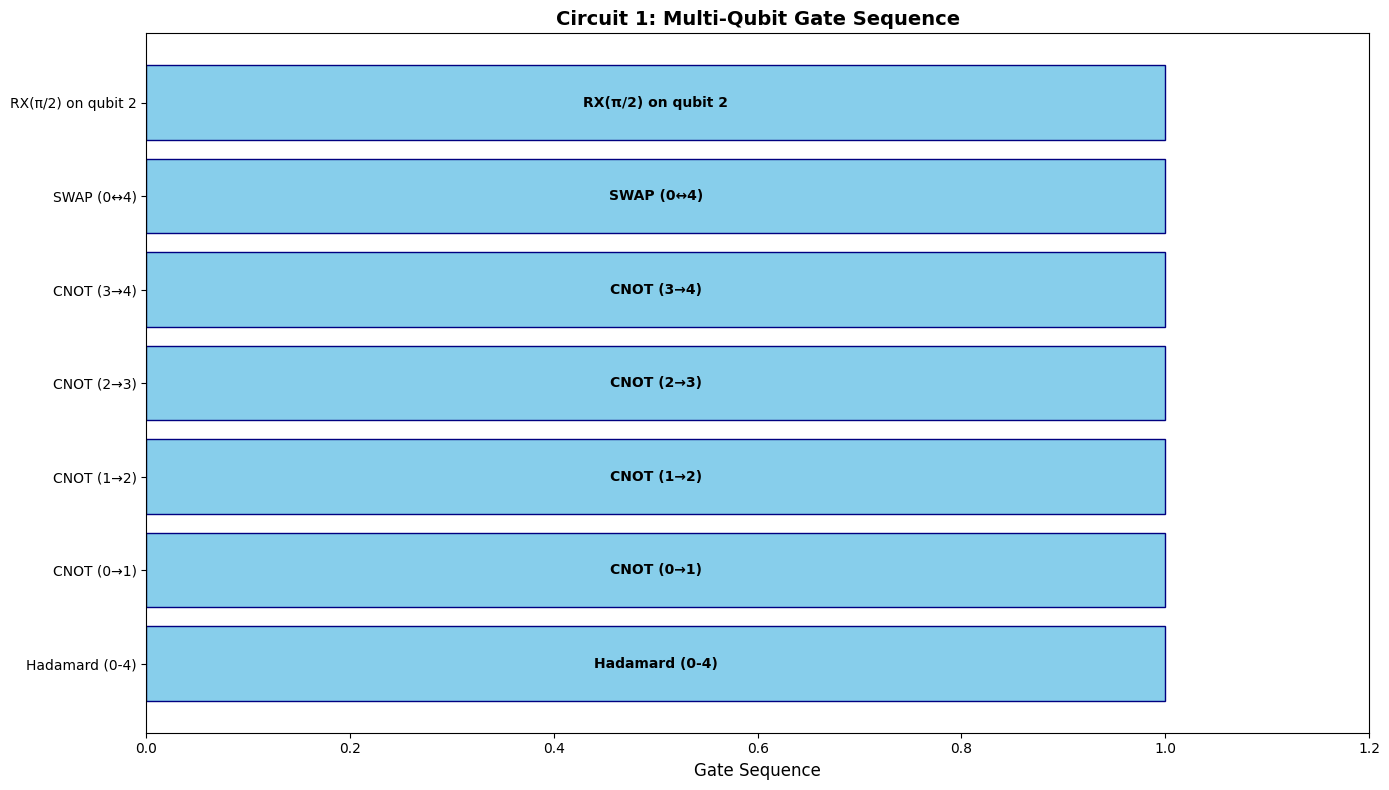

Circuit 1 visualization saved as 'circuit_1_visualization.png'


In [4]:
def visualize_circuit_1():
    """
    Visual representation of Circuit 1 operations
    """
    fig, ax = plt.subplots(figsize=(14, 8))

    # Define gate positions
    gate_sequence = [
        "Hadamard (0-4)",
        "CNOT (0→1)",
        "CNOT (1→2)",
        "CNOT (2→3)",
        "CNOT (3→4)",
        "SWAP (0↔4)",
        "RX(π/2) on qubit 2"
    ]

    # Plot circuit structure
    y_positions = np.arange(len(gate_sequence))
    ax.barh(y_positions, [1]*len(gate_sequence), color='skyblue', edgecolor='navy')
    ax.set_yticks(y_positions)
    ax.set_yticklabels(gate_sequence)
    ax.set_xlabel('Gate Sequence', fontsize=12)
    ax.set_title('Circuit 1: Multi-Qubit Gate Sequence', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1.2)

    # Add text annotations
    for i, (y, gate) in enumerate(zip(y_positions, gate_sequence)):
        ax.text(0.5, y, gate, ha='center', va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('circuit_1_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Circuit 1 visualization saved as 'circuit_1_visualization.png'")

visualize_circuit_1()

# Part 2: Circuit 2 - Swap Test

**Requirements:**
- Hadamard gate on qubit 0
- RX(π/3) rotation on qubit 1
- Hadamard gates on qubits 2 and 3
- Swap test between states |q0 q1⟩ and |q2 q3⟩

**Note:** Swap test is used to measure the overlap between two quantum states.
________________________________________________________
Swap Test Requirements:

The Swap Test is a fundamental quantum circuit used to measure the similarity or overlap between two unknown quantum states. Here's why each component is necessary:

Hadamard gate on qubit 0 ($H_0$$H_0$):

Purpose: This gate is used to prepare the first qubit of the first quantum state ($|\psi_1\rangle$$|\psi_1\rangle$) in a superposition. A Hadamard gate transforms $|0\rangle$$|0\rangle$ into $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$$|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ and $|1\rangle$$|1\rangle$ into $|-\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$$|-\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$. This creates a foundational component for the state to be tested.
Mathematical Representation: $H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$
RX($\pi/3$$\pi/3$) rotation on qubit 1 ($R_X(\pi/3)_1$$R_X(\pi/3)_1$):

_________________________________________________________________
Let's break down those symbols! You've got a couple of important gates there, the Hadamard and the RX (rotation around X-axis) gate.

The Hadamard Gate: $H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$
This funny-looking square of numbers is a special instruction for our qubit.

Imagine your qubit is like a light switch, it can be either OFF (we call this state $|0\rangle$$|0\rangle$) or ON (we call this state $|1\rangle$$|1\rangle$).

When you apply a Hadamard gate to a qubit:

If the qubit was OFF ($|0\rangle$$|0\rangle$), it turns into a special 'blended' state where it's half OFF and half ON at the same time! We call this state $|+\rangle$$|+\rangle$.
If the qubit was ON ($|1\rangle$$|1\rangle$), it also turns into a 'blended' state, but a slightly different one, where it's half OFF and half ON, but with a 'flip' for the ON part. We call this state $|-\rangle$$|-\rangle$.
So, the Hadamard gate is like magic: it takes a definite ON or OFF state and makes it super-blended, meaning it can be both things until we look at it! The $\frac{1}{\sqrt{2}}$$\frac{1}{\sqrt{2}}$ part just makes sure everything is balanced properly.

The RX($\pi/3$$\pi/3$) Rotation on Qubit 1: $R_x(\theta) = \begin{pmatrix} \cos(\theta/2) & -i\sin(\theta/2) \\ -i\sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$R_x(\theta) = \begin{pmatrix} \cos(\theta/2) & -i\sin(\theta/2) \\ -i\sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$
Now, for the RX gate, imagine your qubit as a little spinning top (like a 'Bloch sphere'). It has an imaginary axis going through it from left to right, which we call the X-axis.

An RX gate means you're giving the spinning top a push to make it spin (or rotate) around that X-axis. The $\pi/3$ part tells you how much to push it and how far it should rotate. Here, $\pi/3$$\pi/3$ is an angle (about 60 degrees).

So, RX(π/3) means you're rotating the state of qubit 1 around its X-axis by an angle of $\pi/3$$\pi/3$ radians.
This changes the 'direction' of your qubit's state, making it point to a new place on the spinning top. The numbers in the matrix (involving cos and sin of half the angle, and i which is an imaginary number) are just the mathematical recipe for how that rotation happens.
In short: Hadamard creates a blend, and RX precisely tilts the blend!


_________________________________________________________________


Purpose: This is a single-qubit rotation gate that rotates the state vector around the X-axis of the Bloch sphere by an angle of $\pi/3$$\pi/3$ radians. It's used to prepare the second qubit of the first quantum state ($|\psi_1\rangle$$|\psi_1\rangle$) in a specific, non-trivial superposition, making the state more complex and demonstrating a more general case for the overlap test.
Mathematical Representation: $R_x(\theta) = \begin{pmatrix} \cos(\theta/2) & -i\sin(\theta/2) \\ -i\sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$
Hadamard gates on qubits 2 and 3 ($H_2, H_3$):

Purpose: Similar to qubit 0, these Hadamard gates are used to prepare the two qubits that form the second quantum state ($|\psi_2\rangle$$|\psi_2\rangle$) in superposition. By preparing both qubits of the second state with Hadamards, we create another specific state whose overlap with $|\psi_1\rangle$$|\psi_1\rangle$ will be measured.
Mathematical Representation: $H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$
Swap test between states $|q_0q_1\rangle$ and $|q_2q_3\rangle$:

Purpose: This is the core of the circuit. The Swap Test algorithm requires an auxiliary (ancilla) qubit, typically initialized in a superposition (e.g., $|+\rangle$$|+\rangle$ using a Hadamard gate). This ancilla qubit controls a series of Controlled-SWAP (CSWAP) operations. Each CSWAP gate swaps corresponding qubits from the two states being compared, conditional on the ancilla being in the $|1\rangle$$|1\rangle$ state. After a final Hadamard on the ancilla, measuring its expectation value (e.g., $Z$$Z$) reveals the overlap between the two states.
How it works: If the two states are identical, the CSWAP operations effectively do nothing (or swap identical states back to their original positions), and the ancilla remains in a state that yields a high probability of measuring $|0\rangle$$|0\rangle$. If the states are orthogonal, the CSWAP causes maximal disturbance, leading to an equal probability of measuring $|0\rangle$$|0\rangle$ or $|1\rangle$$|1\rangle$ on the ancilla (or specifically, a lower probability of measuring $|0\rangle$$|0\rangle$ and higher probability of measuring $|1\rangle$$|1\rangle$).
Note: The use of two pairs of qubits ($|q_0q_1\rangle$$|q_0q_1\rangle$ and $|q_2q_3\rangle$$|q_2q_3\rangle$) means the Swap Test is performed on two-qubit states, requiring two CSWAP operations (one for each corresponding pair of qubits: $q_0 \leftrightarrow q_2$$q_0 \leftrightarrow q_2$ and $q_1 \leftrightarrow q_3$$q_1 \leftrightarrow q_3$) controlled by the same ancilla. This generalizes the test to multi-qubit states.
Result Interpretation: The expectation value of the Pauli-Z operator on the ancilla qubit, $\langle Z_{\text{ancilla}} \rangle$$\langle Z_{\text{ancilla}} \rangle$, is directly related to the overlap $|\langle\psi_1|\psi_2\rangle|^2$$|\langle\psi_1|\psi_2\rangle|^2$ by the formula: $$|\langle\psi_1|\psi_2\rangle|^2 = \frac{1 + \langle Z_{\text{ancilla}} \rangle}{2}$$ Thus, by measuring the ancilla, we can quantify the similarity of the two unknown quantum states.

In [5]:
import pennylane as qml
import jax.numpy as jnp

# Define a device with 5 qubits for JAX execution (qubit 4 as ancilla for swap test)
dev2_jax = qml.device('default.qubit', wires=5)

@qml.qnode(dev2_jax, interface='jax')
def circuit_2_jax():
    """
    Circuit 2 (JAX version): Swap Test

    Measures the overlap/similarity between two quantum states:
    - State 1: qubits 0 and 1
    - State 2: qubits 2 and 3
    - Ancilla qubit: qubit 4
    """

    # Step 1: Prepare first state on qubits 0-1
    qml.Hadamard(wires=0)          # H on qubit 0
    qml.RX(jnp.pi/3, wires=1)      # RX(π/3) on qubit 1 using jax.numpy

    # Step 2: Prepare second state on qubits 2-3
    qml.Hadamard(wires=2)          # H on qubit 2
    qml.Hadamard(wires=3)          # H on qubit 3

    # Step 3: Initialize ancilla qubit in superposition
    qml.Hadamard(wires=4)          # Ancilla in |+⟩

    # Step 4: Controlled-SWAP operations
    qml.CSWAP(wires=[4, 0, 2])
    qml.CSWAP(wires=[4, 1, 3])

    # Step 5: Final Hadamard on ancilla
    qml.Hadamard(wires=4)

    # Return measurements
    return qml.expval(qml.PauliZ(4))

# Run the JAX circuit
result2_jax = circuit_2_jax()
print("\n=== CIRCUIT 2 (JAX) RESULTS ===")
print(f"Swap test ancilla measurement (Z expectation): {result2_jax:.4f}")
print(f"Overlap between states (interpretation): {(1 - result2_jax)/2:.4f}")


=== CIRCUIT 2 (JAX) RESULTS ===
Swap test ancilla measurement (Z expectation): 0.5000
Overlap between states (interpretation): 0.2500


## Visualization of Circuit 2

In [6]:
print("\n=== CIRCUIT 2 (JAX) DIAGRAM ===")
print(qml.draw(circuit_2_jax)())


=== CIRCUIT 2 (JAX) DIAGRAM ===
0: ──H────────╭SWAP──────────┤     
1: ──RX(1.05)─│─────╭SWAP────┤     
2: ──H────────├SWAP─│────────┤     
3: ──H────────│─────├SWAP────┤     
4: ──H────────╰●────╰●─────H─┤  <Z>


## Detailed Swap Test Explanation

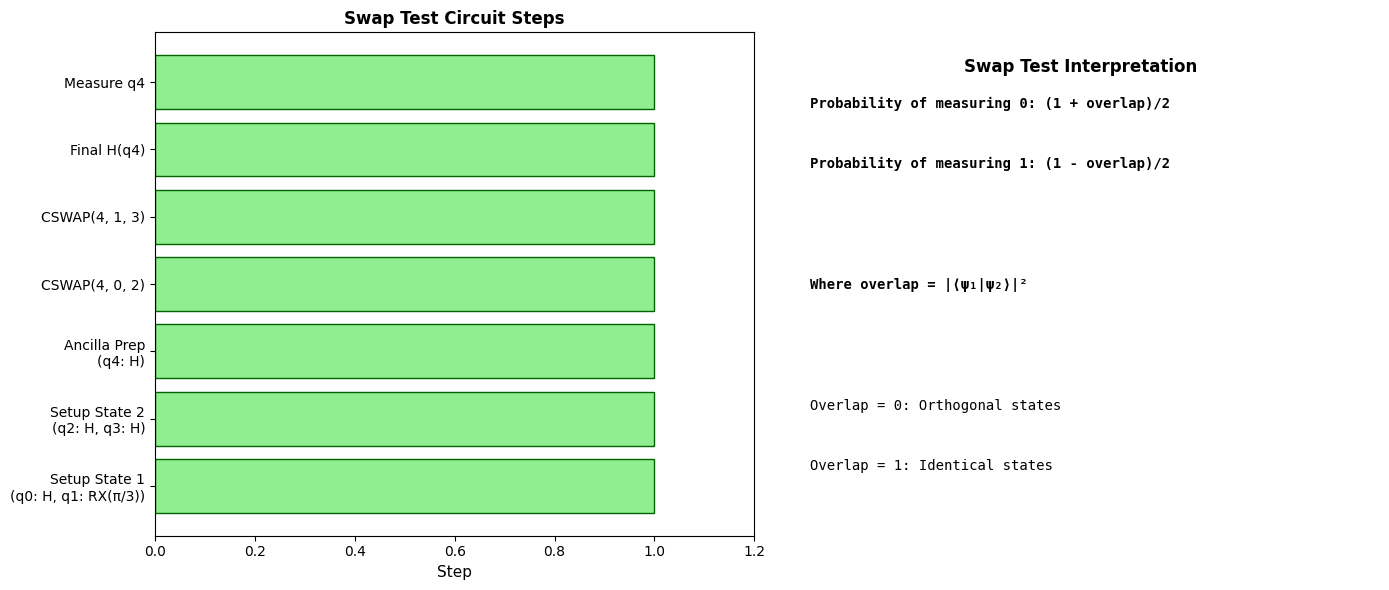

Swap test visualization saved as 'circuit_2_swap_test.png'


In [7]:
def visualize_swap_test():
    """
    Visual explanation of the Swap Test algorithm
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left panel: Circuit steps
    ax = axes[0]
    steps = [
        "Setup State 1\n(q0: H, q1: RX(π/3))",
        "Setup State 2\n(q2: H, q3: H)",
        "Ancilla Prep\n(q4: H)",
        "CSWAP(4, 0, 2)",
        "CSWAP(4, 1, 3)",
        "Final H(q4)",
        "Measure q4"
    ]

    y_pos = np.arange(len(steps))
    ax.barh(y_pos, [1]*len(steps), color='lightgreen', edgecolor='darkgreen')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(steps, fontsize=10)
    ax.set_xlabel('Step', fontsize=11)
    ax.set_title('Swap Test Circuit Steps', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.2)

    # Right panel: Interpretation
    ax = axes[1]
    interpretations = [
        "Probability of measuring 0: (1 + overlap)/2",
        "Probability of measuring 1: (1 - overlap)/2",
        "",
        "Where overlap = |⟨ψ₁|ψ₂⟩|²",
        "",
        "Overlap = 0: Orthogonal states",
        "Overlap = 1: Identical states"
    ]

    ax.text(0.5, 0.95, 'Swap Test Interpretation', ha='center', va='top',
            fontsize=12, fontweight='bold', transform=ax.transAxes)

    y_start = 0.85
    for i, text in enumerate(interpretations):
        y = y_start - i*0.12
        if text:
            fontweight = 'bold' if 'Probability' in text or 'overlap' in text else 'normal'
            ax.text(0.05, y, text, fontsize=10, fontweight=fontweight,
                   transform=ax.transAxes, family='monospace')

    ax.axis('off')

    plt.tight_layout()
    plt.savefig('circuit_2_swap_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Swap test visualization saved as 'circuit_2_swap_test.png'")

visualize_swap_test()

## Comparison and Analysis

In [8]:
print("\n" + "="*60)
print("CIRCUIT COMPARISON AND ANALYSIS")
print("="*60)

print("\n--- CIRCUIT 1: Multi-Qubit Gates ---")
print(f"Number of qubits: 5")
print(f"Hadamard gates: 5 (on all qubits)")
print(f"CNOT gates: 4 (chain operation)")
print(f"SWAP gates: 1")
print(f"RX gates: 1 (rotation angle: π/2)")
print(f"Total gate count: 11 gates")
print(f"Purpose: Demonstrates fundamental quantum operations and entanglement")

print("\n--- CIRCUIT 2: Swap Test ---")
print(f"Number of qubits: 5 (2 for state 1, 2 for state 2, 1 ancilla)")
print(f"Hadamard gates: 4 (state prep) + 2 (ancilla)")
print(f"RX gates: 1 (rotation angle: π/3)")
print(f"CSWAP (Fredkin) gates: 2")
print(f"Purpose: Measures overlap between two quantum states")
print(f"Overlap result: {(1 - result2_jax)/2:.4f}") # Changed to result2_jax

print("\n--- KEY QUANTUM CONCEPTS DEMONSTRATED ---")
print("1. Superposition: Hadamard gates create equal superposition")
print("2. Entanglement: CNOT chain creates Bell-like states")
print("3. State Swapping: SWAP and CSWAP operations")
print("4. Rotation: RX gates rotate around X-axis")
print("5. Measurement: Z-basis measurements on qubits")
print("6. Swap Test: Computes overlap between two quantum states")


CIRCUIT COMPARISON AND ANALYSIS

--- CIRCUIT 1: Multi-Qubit Gates ---
Number of qubits: 5
Hadamard gates: 5 (on all qubits)
CNOT gates: 4 (chain operation)
SWAP gates: 1
RX gates: 1 (rotation angle: π/2)
Total gate count: 11 gates
Purpose: Demonstrates fundamental quantum operations and entanglement

--- CIRCUIT 2: Swap Test ---
Number of qubits: 5 (2 for state 1, 2 for state 2, 1 ancilla)
Hadamard gates: 4 (state prep) + 2 (ancilla)
RX gates: 1 (rotation angle: π/3)
CSWAP (Fredkin) gates: 2
Purpose: Measures overlap between two quantum states
Overlap result: 0.2500

--- KEY QUANTUM CONCEPTS DEMONSTRATED ---
1. Superposition: Hadamard gates create equal superposition
2. Entanglement: CNOT chain creates Bell-like states
3. State Swapping: SWAP and CSWAP operations
4. Rotation: RX gates rotate around X-axis
5. Measurement: Z-basis measurements on qubits
6. Swap Test: Computes overlap between two quantum states
